In [1]:
#Data Cleqning

In [1]:
#Ingest all sheets with pandas.read_excel().

import pandas as pd
import numpy as np
import os
from datetime import datetime

# Load all CSVs
customers = pd.read_csv("Customers.csv")
models = pd.read_csv("MobileModels.csv")
shops = pd.read_csv("ShopLocations.csv")
sales = pd.read_csv("Sales.csv")
stocks = pd.read_csv("Stocks.csv")
offers = pd.read_csv("Offers.csv")

# Store in a dictionary for easy iteration
datasets = {
    "Customers": customers,
    "MobileModels": models,
    "ShopLocations": shops,
    "Sales": sales,
    "Stocks": stocks,
    "Offers": offers
}

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
# Clean email column
customers['email'] = customers['email'].astype(str).str.strip()

customers.loc[
    customers['email'].isin(['', ' ', '-', '--', '---', '.', 'nan', 'NaN', 'NULL', 'null', 'None', 'none']),
    'email'
] = "NA"

# Save back to file
customers.to_csv("customers.csv", index=False)


In [4]:
df2 = pd.read_csv("Customers_with_names_split.csv")


# Convert to clean string
df2['email'] = df2['email'].astype(str).str.strip()

# Replace invalid values with "NA"
df2.loc[
    df2['email'].isin(['', ' ', '-', '--', '---', '.', 'nan', 'NaN', 'NULL', 'null', 'None', 'none', 'N/A', 'n/a']),
    'email'
] = "NA"

df2.to_csv("Customers_with_names_split.csv", index=False)



In [5]:
for file in ["customers.csv", "Customers_with_names_split.csv"]:
    df = pd.read_csv(file)
    
    # Convert phone to string
    df['phone'] = df['phone'].astype(str).str.strip()

    # Remove .0 if present
    df['phone'] = df['phone'].str.replace('.0', '', regex=False)

    # Extract only digits
    df['phone'] = df['phone'].str.extract(r'(\d+)')

    # Replace non-digit or empty with NA
    df.loc[df['phone'].isin(['', ' ', 'nan', 'NaN', None]), 'phone'] = "NA"

    # Replace phone numbers not equal to 10 digits with NA
    df.loc[df['phone'].str.len() != 10, 'phone'] = "NA"

    # Save file
    df.to_csv(file, index=False)
    print("Updated:", file)


Updated: customers.csv
Updated: Customers_with_names_split.csv


In [6]:
df2 = pd.read_csv("Customers_with_names_split.csv")


# Convert to clean string
df2['email'] = df2['email'].astype(str).str.strip()

# Replace invalid values with "NA"
df2.loc[
    df2['email'].isin(['', ' ', '-', '--', '---', '.', 'nan', 'NaN', 'NULL', 'null', 'None', 'none', 'N/A', 'n/a']),
    'email'
] = "NA"

df2.to_csv("Customers_with_names_split.csv", index=False)

In [7]:
import os
import pandas as pd

folder_path = r"C:\Users\TANU\Documents\EDA"

csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".csv")]

missing_summary = {}

print("MISSING VALUE SUMMARY:\n")

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    
    print(f"\n--- {file} ---")
    print(df.isnull().sum())
    
    # Store summary for visualization
    missing_summary[file] = df.isnull().sum()


MISSING VALUE SUMMARY:


--- Customers.csv ---
customer_id         0
full_name           0
email             311
phone             764
city                0
loyalty_points    604
dtype: int64

--- customers_cleaned.csv ---
customer_id         0
full_name           0
email             311
phone             234
city                0
loyalty_points    604
dtype: int64

--- Customers_with_names_split.csv ---
customer_id         0
full_name           0
email             311
phone             764
city                0
loyalty_points    604
first_name          0
last_name           0
dtype: int64

--- DataDictionary.csv ---
info    0
dtype: int64

--- Data_Metadata_Summary.csv ---
dataset           0
rows              0
columns           0
missing_values    0
duplicate_rows    0
last_updated      0
file_size_kb      0
dtype: int64

--- MobileModels.csv ---
model_id      0
brand         0
model_name    0
ram_gb        0
storage_gb    0
price         0
dtype: int64

--- models_avg_price_by_bran

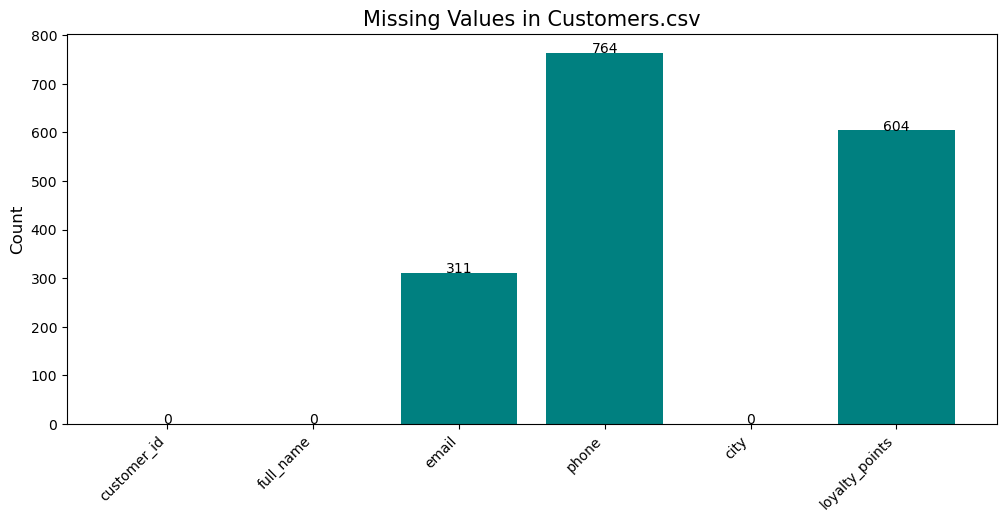

interactive(children=(Dropdown(description='Select File:', layout=Layout(width='400px'), options=('Customers.c…

<function __main__.show_missing_values(selected_file)>

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

folder_path = r"C:\Users\TANU\Documents\EDA"

# List CSV files dynamically
csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".csv")]

# Dropdown widget for file selection
dropdown = widgets.Dropdown(
    options=csv_files,
    description="Select File:",
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

# Function to update graph when user selects a file
def show_missing_values(selected_file):
    file_path = os.path.join(folder_path, selected_file)
    df = pd.read_csv(file_path)

    missing_counts = df.isnull().sum()

    # Create figure with extra space at bottom
    fig, ax = plt.subplots(figsize=(12,6))
    
    ax.bar(missing_counts.index, missing_counts.values, color="teal")
    ax.set_title(f"Missing Values in {selected_file}", fontsize=15)
    ax.set_ylabel("Count", fontsize=12)
    
    # Rotate labels for better visibility
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Add value labels above bars
    for i, v in enumerate(missing_counts.values):
        ax.text(i, v + 0.2, str(v), ha='center', fontsize=10)

    # Adjust layout without warning
    plt.subplots_adjust(bottom=0.25, top=0.90)

    plt.show()

# Display widget + interaction
widgets.interact(show_missing_values, selected_file=dropdown)


In [9]:
#Handling The Missing Values

In [10]:
import pandas as pd

files = ["Customers.csv", "Customers_with_names_split.csv"]

invalid_email_values = [
    "", " ", "-", "--", "---", ".", 
    "nan", "NaN", "NULL", "null", 
    "None", "none", "N/A", "n/a"
]

for file in files:
    df = pd.read_csv(file)
    
    # Convert to clean string
    df['email'] = df['email'].astype(str).str.strip()

    # Replace all invalid/wrong email values with real NaN
    df['email'] = df['email'].replace(invalid_email_values, pd.NA)

    # Convert NaN → "NA"
    df['email'] = df['email'].fillna("NA")

    # Save changes
    df.to_csv(file, index=False)
    print("Updated:", file)


Updated: Customers.csv
Updated: Customers_with_names_split.csv


In [11]:
import pandas as pd
import numpy as np

files = ["Customers.csv", "Customers_with_names_split.csv"]

invalid_values = [
    "", " ", "-", "--", "---", ".", 
    "nan", "NaN", "NULL", "null", 
    "None", "none", "N/A", "n/a"
]

for file in files:
    df = pd.read_csv(file)

    print("Processing:", file)

    # -------- EMAIL CLEANING --------
    if 'email' in df.columns:
        df['email'] = df['email'].astype(str).str.strip()
        df['email'] = df['email'].replace(invalid_values, np.nan)
        df['email'] = df['email'].fillna("NA")
    else:
        print("Warning: 'email' column not found in", file)

    # -------- PHONE CLEANING --------
    if 'phone' in df.columns:
        df['phone'] = df['phone'].astype(str).str.strip()
        df['phone'] = df['phone'].str.replace('.0', '', regex=False)
        df['phone'] = df['phone'].str.extract(r'(\d+)')

        # Convert invalid to NA
        df.loc[df['phone'].isin([None, "", " ", "nan", "NaN"]), 'phone'] = "NA"

        # Keep only 10-digit numbers
        df.loc[df['phone'].str.len() != 10, 'phone'] = "NA"
    else:
        print("Warning: 'phone' column not found in", file)

    # SAVE UPDATED FILE
    df.to_csv(file, index=False)
    print("Updated:", file, "\n")


Processing: Customers.csv
Updated: Customers.csv 

Processing: Customers_with_names_split.csv
Updated: Customers_with_names_split.csv 



In [12]:
#Finding repeat customers
# Count number of purchases per customer
purchase_counts = sales.groupby('customer_id').size()

# Filter customers who purchased more than once
repeat_customer_ids = purchase_counts[purchase_counts > 1].index

repeat_customer_ids


Index(['CUST1000', 'CUST1001', 'CUST1002', 'CUST1003', 'CUST1004', 'CUST1005',
       'CUST1007', 'CUST1008', 'CUST1009', 'CUST1010',
       ...
       'CUST6990', 'CUST6991', 'CUST6992', 'CUST6993', 'CUST6994', 'CUST6995',
       'CUST6996', 'CUST6997', 'CUST6998', 'CUST6999'],
      dtype='object', name='customer_id', length=5940)

In [13]:
import pandas as pd

customers = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Customers.csv")
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")

# Count purchases per customer
purchase_counts = sales.groupby('customer_id').size()

# Get IDs of repeat customers
repeat_ids = purchase_counts[purchase_counts > 1].index

# Filter customer details
repeat_customers = customers[customers['customer_id'].isin(repeat_ids)]

# PRINT
print("Repeat Customers (Full Details):")
print(repeat_customers)
print("\nTotal Repeat Customers:", repeat_customers.shape[0])


Repeat Customers (Full Details):
     customer_id      full_name                         email         phone  \
0       CUST1000   Arjun Sharma      ishita.shah834@gmail.com  5.157282e+09   
1       CUST1001   Arjun Sharma  ishita.kulkarni493@gmail.com  1.790139e+09   
2       CUST1002    Ishita Nair   kabir.kulkarni532@gmail.com           NaN   
3       CUST1003   Rohan Sharma       priya.shah127@gmail.com           NaN   
4       CUST1004    Anaya Patel                           NaN  5.215388e+09   
...          ...            ...                           ...           ...   
5995    CUST6995   Arjun Kapoor       rohan.patel66@gmail.com  1.459028e+09   
5996    CUST6996     Sneha Khan    suresh.kapoor138@gmail.com           NaN   
5997    CUST6997      Arjun Das        mira.shah580@gmail.com  4.831152e+09   
5998    CUST6998    Anaya Patel   priya.kulkarni257@gmail.com  7.289856e+09   
5999    CUST6999  Suresh Sharma    rahul.kulkarni59@gmail.com  6.613246e+09   

           city  l

In [14]:
purchase_counts = sales.groupby('customer_id').size()
repeat_ids = purchase_counts[purchase_counts > 1].index
repeat_customers = customers[customers['customer_id'].isin(repeat_ids)]
missing_loyalty_repeat = repeat_customers[repeat_customers['loyalty_points'] == 0]

print("Repeat customers with missing loyalty points:")
print(missing_loyalty_repeat)

print("\nTotal such customers:", missing_loyalty_repeat.shape[0])


Repeat customers with missing loyalty points:
Empty DataFrame
Columns: [customer_id, full_name, email, phone, city, loyalty_points]
Index: []

Total such customers: 0


In [15]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\TANU\Documents\EDA\Customers.csv"

df = pd.read_csv(file_path)

# 1) FIX EMAIL (invalid/empty → NA)
invalid_email_values = ["", " ", "-", "--", "---", ".", 
                        "nan", "NaN", "NULL", "null", 
                        "None", "none", "N/A", "n/a"]

df['email'] = df['email'].astype(str).str.strip()
df['email'] = df['email'].replace(invalid_email_values, np.nan)
df['email'] = df['email'].fillna("NA")

# 2) FIX PHONE (invalid/short/empty → NA)
df['phone'] = df['phone'].astype(str).str.strip()
df['phone'] = df['phone'].str.replace('.0', '', regex=False)
df['phone'] = df['phone'].str.extract(r'(\d+)')
df.loc[df['phone'].isin([None, "", " ", "nan", "NaN"]), 'phone'] = "NA"
df.loc[df['phone'].str.len() != 10, 'phone'] = "NA"

# 3) FIX LOYALTY POINTS (missing → 0)
# Reason: Repeat customers had no missing loyalty points,
# so missing values belong to one-time buyers who have not earned points yet.

df['loyalty_points'] = df['loyalty_points'].fillna(0)

# SAVE FINAL COMBINED CLEANED DATA
df.to_csv(file_path, index=False)

print("Email, phone, and loyalty_points cleaned and saved successfully!")

Email, phone, and loyalty_points cleaned and saved successfully!


In [16]:
# We are imputing missing discount values using the 
# MODEL-WISE MEDIAN discount.
#Step 1: Convert blanks to NaN
import pandas as pd
import numpy as np

sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")

# Clean column names
sales.columns = sales.columns.str.strip().str.lower()

# Convert blank discount values ("") to real NaN
sales['discount'] = sales['discount'].replace(["", " "], np.nan)


In [17]:
import pandas as pd
import numpy as np

sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")

# MODEL-WISE MEDIAN
model_median = sales.groupby('model_id')['discount'].median()

# IMPUTATION USING ONLY MODEL-WISE MEDIAN
def fill_discount(row):
    if pd.isna(row['discount']):
        return model_median[row['model_id']]   # only model median
    return row['discount']

sales['discount'] = sales.apply(fill_discount, axis=1)

print("Missing discount after model-wise fill:", sales['discount'].isnull().sum())

sales.to_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv", index=False)


Missing discount after model-wise fill: 0


In [18]:
#Round discount to 2 decimel places
import pandas as pd

sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")

# Round discount values to 2 decimal places
sales['discount'] = sales['discount'].round(2)

# Save cleaned file
sales.to_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv", index=False)

print("Discount column successfully rounded to 2 decimal places!")


Discount column successfully rounded to 2 decimal places!


In [19]:
import pandas as pd
import numpy as np

# Load datasets
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# We fill missing final_price using the REAL retail formula:
# final_price = base_price * quantity * (1 - discount/100)
#
# Reason:
# This method exactly matches how billing systems calculate the 
# price the customer actually pays after discount. 
# It is the most accurate and business-correct way to fix missing values.

# Merge to bring in base model price
sales = sales.merge(models[['model_id', 'price']], on='model_id', how='left')

# Recalculate only where final_price is missing
def fix_final_price(row):
    if pd.isna(row['final_price']):
        return row['price'] * row['quantity'] * (1 - row['discount'] / 100)
    return row['final_price']

sales['final_price'] = sales.apply(fix_final_price, axis=1)

# Round to nearest rupee
sales['final_price'] = sales['final_price'].round(0)

# Drop temporary base price column
sales = sales.drop(columns=['price'])

# Save cleaned file
sales.to_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv", index=False)

print("Missing final_price values successfully recalculated and saved!")


Missing final_price values successfully recalculated and saved!


In [20]:
import pandas as pd

# Load file
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")

# Show missing values per column
print("Missing values in each column:\n")
print(sales.isnull().sum())

# Check total missing values
print("\nTotal missing values:", sales.isnull().sum().sum())


Missing values in each column:

sale_id         0
customer_id     0
model_id        0
shop_id         0
sale_date       0
quantity        0
discount        0
final_price     0
payment_mode    0
status          0
dtype: int64

Total missing values: 0


In [21]:
#Filling missing stock vlues with median
import pandas as pd
import numpy as np

stocks = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Stocks.csv")

# Clean column names
stocks.columns = stocks.columns.str.strip().str.lower()

# 1) Convert blanks (if any) to NaN
stocks['available_units'] = stocks['available_units'].replace(["", " "], np.nan)

# 2) Model+Shop wise median
group_median = stocks.groupby(['shop_id', 'model_id'])['available_units'].median()

# 3) Overall median fallback
overall_median = stocks['available_units'].median()

# 4) Impute missing values
def fill_stock(row):
    if pd.isna(row['available_units']):
        m = group_median.get((row['shop_id'], row['model_id']), np.nan)
        return overall_median if pd.isna(m) else m
    return row['available_units']

stocks['available_units'] = stocks.apply(fill_stock, axis=1)

# 5) Round final units
stocks['available_units'] = stocks['available_units'].round(0)

# Save back
stocks.to_csv(r"C:\Users\TANU\Documents\EDA\Stocks.csv", index=False)

print("Missing stock units filled successfully!")


Missing stock units filled successfully!


In [22]:
stocks['available_units'].isnull().sum()


np.int64(0)

In [23]:
import pandas as pd

# Load customers dataset
customers = pd.read_csv("Customers.csv")

# 1) Check for full-row duplicates
full_duplicates = customers.duplicated().sum()

# 2) Check for duplicates based only on customer_id column
id_duplicates = customers['customer_id'].duplicated().sum()

# 3) Check duplicates ignoring keep logic (full check again)
all_duplicates = customers.duplicated(keep=False).sum()

# Print results
print("Full-row duplicates:", full_duplicates)
print("Duplicate customer_id entries:", id_duplicates)
print("Any repeated rows (strict check):", all_duplicates)


Full-row duplicates: 0
Duplicate customer_id entries: 0
Any repeated rows (strict check): 0


In [24]:
import pandas as pd
import numpy as np

sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")

# Select only numeric columns
numeric_cols = sales.select_dtypes(include=[np.number]).columns

negative_counts = {}

for col in numeric_cols:
    negative_counts[col] = (sales[col] < 0).sum()

print("Negative values per column:\n")
for col, count in negative_counts.items():
    print(f"{col}: {count}")


Negative values per column:

quantity: 0
discount: 0
final_price: 244


In [25]:
import pandas as pd

sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

merged = sales.merge(models[['model_id','price']], on='model_id', how='left')

print("Missing price rows:")
missing_price = merged[merged['price'].isna()]
print(missing_price.shape)
print(missing_price.head())


Missing price rows:
(0, 11)
Empty DataFrame
Columns: [sale_id, customer_id, model_id, shop_id, sale_date, quantity, discount, final_price, payment_mode, status, price]
Index: []


In [26]:
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

print(models[models['model_id'] == 'MOD2111'])


    model_id   brand model_name  ram_gb  storage_gb  price
111  MOD2111  realme    Series6       4          64   -660


In [27]:
import pandas as pd

models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

similar_specs = models[(models['ram_gb'] == 4) & 
                       (models['storage_gb'] == 64) &
                       (models['price'] > 0)]

median_price_4_64 = similar_specs['price'].median()
print("Median price for all 4GB/64GB models:", median_price_4_64)


Median price for all 4GB/64GB models: 22553.0


In [28]:
import pandas as pd

models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# Update the incorrect price
models.loc[models['model_id'] == 'MOD2111', 'price'] = 22553.0

# Save updated models file
models.to_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv", index=False)

print("MOD2111 price fixed to 22553.0")


MOD2111 price fixed to 22553.0


In [29]:
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# Merge to bring correct prices
sales = sales.merge(models[['model_id','price']], on='model_id', how='left')

# Recalculate final_price for all transactions
sales['final_price'] = sales['price'] * sales['quantity'] * (1 - sales['discount'] / 100)

# Round final price
sales['final_price'] = sales['final_price'].round(0)

# Drop temporary price column
sales = sales.drop(columns=['price'])

# Save cleaned file
sales.to_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv", index=False)

print("Final price recalculated successfully!")


Final price recalculated successfully!


In [30]:
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")
print("Negative final_price values:", (sales['final_price'] < 0).sum())


Negative final_price values: 0


In [31]:
#Detecting Extreme Outliers and fixing them

In [32]:
#20 cheapest phones
import pandas as pd

models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# See the 20 cheapest phones
print(models.sort_values('price').head(20))


    model_id     brand model_name  ram_gb  storage_gb  price
15   MOD2015      OPPO   Series18       6          64   1254
90   MOD2090     Apple    Series2       8         512   2649
17   MOD2017    realme   Series19      12         128   3429
55   MOD2055    Xiaomi   Series12       4          64   4006
18   MOD2018    Xiaomi    Series6       4          64   4278
179  MOD2179    realme   Series10       6         512   5339
199  MOD2199      vivo    Series1       6         512   6068
122  MOD2122    realme   Series12      12         512   7361
150  MOD2150    realme   Series12       8          64   7580
92   MOD2092      vivo    Series7       8          64   7635
48   MOD2048  Motorola   Series16      12         512   7968
174  MOD2174  Motorola   Series19      12         256   9167
11   MOD2011  Motorola    Series3       8         256   9210
86   MOD2086      OPPO   Series13       4         512   9665
88   MOD2088   Samsung    Series2       6         256  10723
80   MOD2080    Xiaomi  

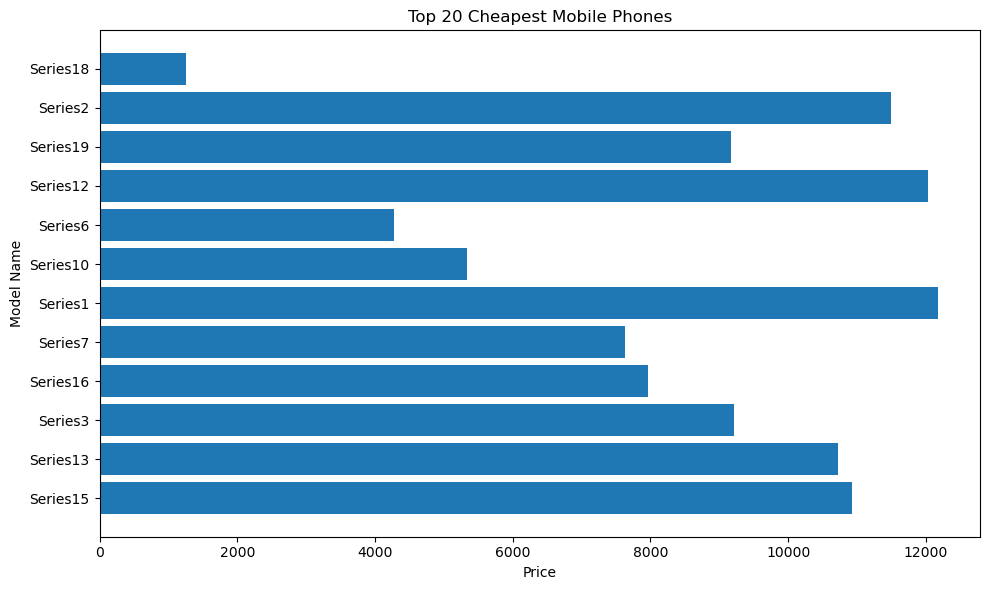

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# Select 20 cheapest phones
cheapest_20 = models.sort_values("price").head(20)

# Plot
plt.figure(figsize=(10,6))
plt.barh(cheapest_20["model_name"], cheapest_20["price"])
plt.xlabel("Price")
plt.ylabel("Model Name")
plt.title("Top 20 Cheapest Mobile Phones")
plt.gca().invert_yaxis()   # Cheapest at top
plt.tight_layout()
plt.show()

    model_id   brand model_name  ram_gb  storage_gb  price
15   MOD2015    OPPO   Series18       6          64   1254
17   MOD2017  realme   Series19      12         128   3429
18   MOD2018  Xiaomi    Series6       4          64   4278
55   MOD2055  Xiaomi   Series12       4          64   4006
90   MOD2090   Apple    Series2       8         512   2649
179  MOD2179  realme   Series10       6         512   5339


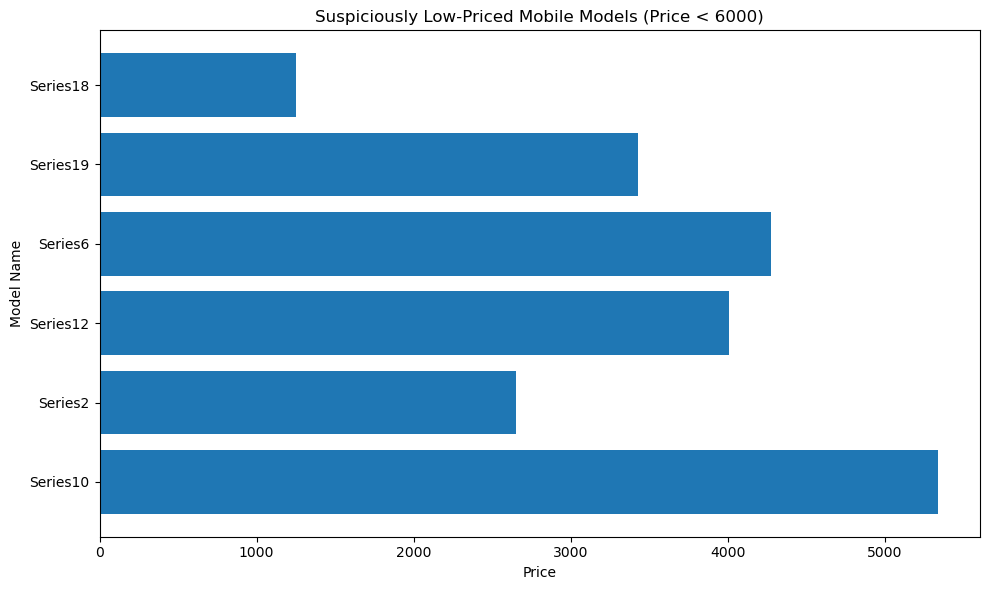

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load models dataset
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# Filter suspiciously cheap phones
suspect = models[models["price"] < 6000]

print(suspect)

# If no data found, handle gracefully
if suspect.empty:
    print("\nNo suspicious entries found (< 6000).")
else:
    plt.figure(figsize=(10,6))
    plt.barh(suspect["model_name"], suspect["price"])

    plt.xlabel("Price")
    plt.ylabel("Model Name")
    plt.title("Suspiciously Low-Priced Mobile Models (Price < 6000)")
    plt.gca().invert_yaxis()  # cheapest at top
    plt.tight_layout()
    plt.show()

In [35]:
import pandas as pd

# Load models file
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# Group by brand and calculate median price
brand_medians = models.groupby("brand")["price"].median().reset_index()

print("Median price for each brand:")
print(brand_medians)


Median price for each brand:
      brand    price
0     Apple  24576.0
1  Motorola  26174.5
2      OPPO  24526.0
3   OnePlus  27020.0
4   Samsung  20881.0
5    Xiaomi  23798.0
6    realme  23808.0
7      vivo  25033.5


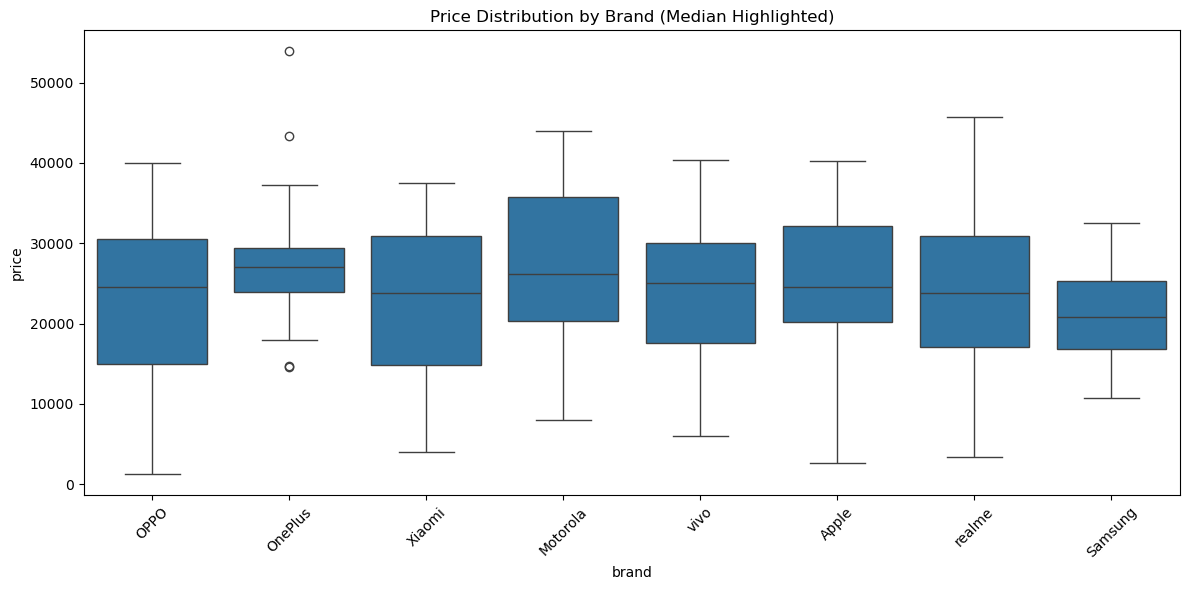

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

plt.figure(figsize=(12,6))
sns.boxplot(x="brand", y="price", data=models)

plt.title("Price Distribution by Brand (Median Highlighted)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
import pandas as pd

models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

apple = models[models['brand'] == 'Apple']

print(apple.sort_values('price'))


    model_id  brand model_name  ram_gb  storage_gb  price
90   MOD2090  Apple    Series2       8         512   2649
26   MOD2026  Apple   Series12       4         256  12023
151  MOD2151  Apple   Series15       4          64  12500
46   MOD2046  Apple    Series4       6         512  17135
98   MOD2098  Apple   Series15      12         128  17186
59   MOD2059  Apple   Series19      12         256  19342
8    MOD2008  Apple   Series19       6         128  21093
139  MOD2139  Apple   Series16       4         512  22101
96   MOD2096  Apple    Series8       8          64  23218
118  MOD2118  Apple    Series9      12         128  23852
41   MOD2041  Apple   Series11       4          64  24412
161  MOD2161  Apple   Series11       4         512  24576
114  MOD2114  Apple    Series7       4          64  24647
30   MOD2030  Apple    Series7      12         512  26510
126  MOD2126  Apple   Series17       8         128  26930
164  MOD2164  Apple   Series10       6          64  27180
177  MOD2177  

In [38]:
#Get median price per storage group
storage_medians = models.groupby('storage_gb')['price'].median()
print(storage_medians)


storage_gb
64     23784.0
128    27021.5
256    25166.0
512    23987.0
Name: price, dtype: float64


In [39]:
#Detect wrong Apple entries
wrong_apple = apple[apple['price'] < 20000]
print(wrong_apple)




    model_id  brand model_name  ram_gb  storage_gb  price
26   MOD2026  Apple   Series12       4         256  12023
46   MOD2046  Apple    Series4       6         512  17135
59   MOD2059  Apple   Series19      12         256  19342
90   MOD2090  Apple    Series2       8         512   2649
98   MOD2098  Apple   Series15      12         128  17186
151  MOD2151  Apple   Series15       4          64  12500


In [40]:
for idx, row in wrong_apple.iterrows():
    storage = row['storage_gb']
    correct_price = storage_medians[storage]

    # Round to nearest integer to fix dtype issue
    models.loc[idx, 'price'] = int(round(correct_price))


In [41]:
models.to_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv", index=False)

print("Fixed Apple prices (rounded to integers).")


Fixed Apple prices (rounded to integers).


In [42]:
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

sales = sales.merge(models[['model_id','price']], on='model_id', how='left')

sales['final_price'] = sales['price'] * sales['quantity'] * (1 - sales['discount'] / 100)
sales['final_price'] = sales['final_price'].round(0)

sales = sales.drop(columns=['price'])

sales.to_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv", index=False)

print("Final price recalculated after Apple corrections!")


Final price recalculated after Apple corrections!


In [43]:
import pandas as pd

models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# IQR for price column
Q1 = models['price'].quantile(0.25)
Q3 = models['price'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Price Lower Limit:", lower_limit)
print("Price Upper Limit:", upper_limit)

# Outliers
price_outliers = models[(models['price'] < lower_limit) | (models['price'] > upper_limit)]

print("\nEXTREME PRICE OUTLIERS:")
print(price_outliers)
print("\nTotal Extreme Outliers in Price:", len(price_outliers))



Price Lower Limit: -761.75
Price Upper Limit: 49450.25

EXTREME PRICE OUTLIERS:
   model_id    brand model_name  ram_gb  storage_gb  price
39  MOD2039  OnePlus   Series10      12         512  53887

Total Extreme Outliers in Price: 1


In [44]:
#Checking Discount Outliers
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")

Q1 = sales['discount'].quantile(0.25)
Q3 = sales['discount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

discount_outliers = sales[(sales['discount'] < lower) | (sales['discount'] > upper)]

print("Discount Lower Limit:", lower)
print("Discount Upper Limit:", upper)

print("\nExtreme Discount Outliers:")
print(discount_outliers.head(20))

print("\nTotal Discount Outliers:", len(discount_outliers))


Discount Lower Limit: -13.530000000000001
Discount Upper Limit: 43.510000000000005

Extreme Discount Outliers:
Empty DataFrame
Columns: [sale_id, customer_id, model_id, shop_id, sale_date, quantity, discount, final_price, payment_mode, status]
Index: []

Total Discount Outliers: 0


In [45]:
#Checking and correcting outliers for all brands
import pandas as pd

# Load models
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# Step 1: Identify unrealistic low prices (< 6000)
wrong_prices = models[models["price"] < 6000]
print("Suspicious models:\n", wrong_prices)

# Pre-calc medians
ram_storage_median = models.groupby(["ram_gb", "storage_gb"])["price"].median()
brand_median = models.groupby("brand")["price"].median()
overall_median = models["price"].median()

# Step 2: Fix prices using hybrid method
for idx, row in wrong_prices.iterrows():
    
    ram = row["ram_gb"]
    storage = row["storage_gb"]
    brand = row["brand"]
    
    # 1) Try RAM + Storage median
    try:
        correct_price = ram_storage_median.loc[(ram, storage)]
    except:
        correct_price = None
    
    # If RAM+Storage not valid → use brand median
    if pd.isna(correct_price) or correct_price <= 0:
        correct_price = brand_median.loc[brand]
    
    # If brand also fails → fallback to overall median
    if pd.isna(correct_price) or correct_price <= 0:
        correct_price = overall_median
    
    # Round to integer
    correct_price = int(round(correct_price))
    
    # Assign fixed price
    models.loc[idx, "price"] = correct_price

# Save corrected models file
models.to_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv", index=False)

print("\nAll suspicious model prices have been corrected successfully!")


Suspicious models:
     model_id   brand model_name  ram_gb  storage_gb  price
15   MOD2015    OPPO   Series18       6          64   1254
17   MOD2017  realme   Series19      12         128   3429
18   MOD2018  Xiaomi    Series6       4          64   4278
55   MOD2055  Xiaomi   Series12       4          64   4006
179  MOD2179  realme   Series10       6         512   5339

All suspicious model prices have been corrected successfully!


In [46]:
import pandas as pd

# Load datasets
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")

# Merge sales with corrected model price
merged = sales.merge(models[["model_id", "price"]], on="model_id", how="left")

# Recalculate final price
merged["final_price"] = merged["price"] * merged["quantity"] * (1 - merged["discount"] / 100)

# Round final_price to 2 decimals
merged["final_price"] = merged["final_price"].round(2)

# Save back to CSV
merged.to_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv", index=False)

print("✔ final_price has been fully recalculated using corrected model prices!")


✔ final_price has been fully recalculated using corrected model prices!


In [47]:
lowest = merged.sort_values("final_price").head(20)
print(lowest[["sale_id", "model_id", "quantity", "discount", "final_price"]])


         sale_id model_id  quantity  discount  final_price
35606  SALE39606  MOD2199         1     29.87      4255.49
13860  SALE17860  MOD2199         1     29.86      4256.10
21296  SALE25296  MOD2199         1     29.58      4273.09
33684  SALE37684  MOD2199         1     29.58      4273.09
32811  SALE36811  MOD2199         1     29.28      4291.29
24599  SALE28599  MOD2199         1     29.10      4302.21
1404    SALE5404  MOD2199         1     29.08      4303.43
34291  SALE38291  MOD2199         1     28.93      4312.53
19817  SALE23817  MOD2199         1     28.36      4347.12
18855  SALE22855  MOD2199         1     28.25      4353.79
24254  SALE28254  MOD2199         1     28.25      4353.79
33257  SALE37257  MOD2199         1     26.80      4441.78
21799  SALE25799  MOD2199         1     26.68      4449.06
31574  SALE35574  MOD2199         1     26.19      4478.79
38393  SALE42393  MOD2199         1     26.07      4486.07
18802  SALE22802  MOD2199         1     26.00      4490.

In [48]:
import pandas as pd
import numpy as np

models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"
sales_fp  = r"C:\Users\TANU\Documents\EDA\Sales.csv"

models = pd.read_csv(models_fp)
sales = pd.read_csv(sales_fp)

# ------------- 1) vivo models overview ----------
vivo_models = models[models['brand'].str.lower() == 'vivo']
print("VIVO MODELS COUNT:", len(vivo_models))
print(vivo_models[['model_id','ram_gb','storage_gb','price']].sort_values('price').to_string(index=False))

print("\nVIVO price summary:")
print(vivo_models['price'].describe())

# ------------- 2) Compare with same RAM+Storage across brands ----------
# For the suspect model MOD2199 find its specs
suspect = models[models['model_id']=='MOD2199']
if suspect.empty:
    print("\nMOD2199 not found in models file.")
else:
    ram = int(suspect['ram_gb'].iloc[0])
    storage = int(suspect['storage_gb'].iloc[0])
    print(f"\nMOD2199 specs: ram_gb={ram}, storage_gb={storage}, current_price={suspect['price'].iloc[0]}")

    same_specs = models[(models['ram_gb']==ram) & (models['storage_gb']==storage)]
    print(f"\nNumber of models with same specs (ram {ram}, storage {storage}):", len(same_specs))
    print(same_specs[['model_id','brand','price']].sort_values('price').to_string(index=False))

    print("\nSame-specs price summary:")
    print(same_specs['price'].describe())

# ------------- 3) Find all suspicious low-price models (threshold adjustable) ----------
threshold = 6000   # change if you want a different cutoff
suspects_all = models[models['price'] < threshold].sort_values('price')
print(f"\nModels with price < {threshold} (suspicious):")
print(suspects_all[['model_id','brand','ram_gb','storage_gb','price']].to_string(index=False))

# ------------- 4) Suggest replacement price per model using RAM+Storage median ----------
# compute median by ram+storage (exclude non-positive prices)
group_median = models[models['price']>0].groupby(['ram_gb','storage_gb'])['price'].median()

def suggest_price(row):
    key = (row['ram_gb'], row['storage_gb'])
    if key in group_median.index:
        return int(round(group_median.loc[key]))
    else:
        # fallback to brand median
        bmedian = models[(models['brand']==row['brand']) & (models['price']>0)]['price'].median()
        return int(round(bmedian)) if pd.notna(bmedian) else int(round(models['price'].median()))

# show suggestions for suspicious models
if not suspects_all.empty:
    print("\nSuggested replacement prices (RAM+Storage median fallback brand):")
    suggestions = []
    for _, r in suspects_all.iterrows():
        suggested = suggest_price(r)
        suggestions.append((r['model_id'], r['brand'], r['ram_gb'], r['storage_gb'], r['price'], suggested))
    print(pd.DataFrame(suggestions, columns=['model_id','brand','ram_gb','storage_gb','current_price','suggested_price']).to_string(index=False))
else:
    print("\nNo suspicious low-price models found under threshold.")

# ------------- 5) OPTIONAL: Apply fixes automatically (UNCOMMENT to run) ----------
apply_fixes = False   # set True to apply fixes automatically
if apply_fixes and not suspects_all.empty:
    for idx, row in suspects_all.iterrows():
        new_price = suggest_price(row)
        models.loc[idx, 'price'] = new_price
    models.to_csv(models_fp, index=False)
    print("\nApplied fixes and saved MobileModels.csv")

    # Recalculate final_price for all sales and save
    models_ref = models[['model_id','price']]
    merged = sales.merge(models_ref, on='model_id', how='left')
    merged['final_price'] = (merged['price'] * merged['quantity'] * (1 - merged['discount']/100)).round(2)
    merged.to_csv(sales_fp, index=False)
    print("Recalculated and saved Sales.csv with new final_price.")
else:
    print("\nNot applying fixes automatically. To apply fixes set apply_fixes = True and re-run.")


VIVO MODELS COUNT: 16
model_id  ram_gb  storage_gb  price
 MOD2199       6         512   6068
 MOD2092       8          64   7635
 MOD2071       4          64  13895
 MOD2184       6          64  16796
 MOD2120       4         128  17772
 MOD2006       4         512  18545
 MOD2062       6         256  19990
 MOD2091       4          64  24937
 MOD2010       4         512  25130
 MOD2101       4         256  27500
 MOD2042       6         128  28744
 MOD2130       4         512  29594
 MOD2012       8         128  31447
 MOD2099      12          64  32367
 MOD2044       8          64  33190
 MOD2128       4          64  40386

VIVO price summary:
count       16.000000
mean     23374.750000
std       9551.172469
min       6068.000000
25%      17528.000000
50%      25033.500000
75%      30057.250000
max      40386.000000
Name: price, dtype: float64

MOD2199 specs: ram_gb=6, storage_gb=512, current_price=6068

Number of models with same specs (ram 6, storage 512): 14
model_id   brand  pri

In [49]:
# Replace all Vivo 6/512 models priced at 6068 with overall median
models.loc[
    (models['brand'] == 'vivo') &
    (models['ram_gb'] == 6) &
    (models['storage_gb'] == 512) &
    (models['price'] == 6068),
    'price'
] = overall_median

# Save updated models file
models.to_csv(models_fp, index=False)

print("Vivo 6/512 price corrected successfully.")


Vivo 6/512 price corrected successfully.


C:\Users\TANU\AppData\Local\Temp\ipykernel_22712\1207816016.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '24971.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  models.loc[


In [50]:
import pandas as pd

models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"

models = pd.read_csv(models_fp)

# Filter 6GB / 512GB models
spec = models[(models['ram_gb'] == 6) & (models['storage_gb'] == 512)]

# Overall median price for 6/512 models
overall_median = spec['price'].median()
print("Overall Median (6/512):", overall_median)

# Fix MOD2199 using overall median
models.loc[models['model_id'] == "MOD2199", "price"] = overall_median

# Save back
models.to_csv(models_fp, index=False)
print("✔ MOD2199 price updated in MobileModels.csv")


Overall Median (6/512): 25857.0
✔ MOD2199 price updated in MobileModels.csv


In [51]:
import pandas as pd

# File paths
sales_fp  = r"C:\Users\TANU\Documents\EDA\Sales.csv"
models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"

# Load files
sales  = pd.read_csv(sales_fp)
models = pd.read_csv(models_fp)

# ---------------- STEP 1: Drop wrong leftover columns ----------------
cols_to_drop = ["price", "brand", "model_name", "ram_gb", "storage_gb", "base_price"]
sales = sales.drop(columns=[c for c in cols_to_drop if c in sales.columns])

# ---------------- STEP 2: Merge correct model data ----------------
merged = sales.merge(
    models[["model_id", "brand", "model_name", "ram_gb", "storage_gb", "price"]],
    on="model_id",
    how="left"
)

# Rename model price to base_price
merged = merged.rename(columns={"price": "base_price"})

# ---------------- STEP 3: Recalculate final_price ----------------
merged["final_price"] = (
    merged["base_price"] * merged["quantity"] * (1 - merged["discount"] / 100)
).round(2)

# ---------------- STEP 4: Save clean Sales.csv ----------------
merged.to_csv(sales_fp, index=False)

print("✔ Sales.csv FIXED successfully!")
print("✔ final_price recalculated cleanly!")



✔ Sales.csv FIXED successfully!
✔ final_price recalculated cleanly!


In [52]:
import pandas as pd

models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"
sales_fp  = r"C:\Users\TANU\Documents\EDA\Sales.csv"

models = pd.read_csv(models_fp)
sales  = pd.read_csv(sales_fp)

# STEP 1 — Fix MODEL base price for vivo MOD2199
correct_price = 25857  # median of all other 6GB/512GB models

models.loc[models["model_id"] == "MOD2199", "price"] = correct_price

# Save updated model file
models.to_csv(models_fp, index=False)


In [53]:
# STEP 2 — Fix final_price in Sales.csv for MOD2199
# Filter rows of that model
mask = sales["model_id"] == "MOD2199"

# Recalculate final price using the corrected base price
sales.loc[mask, "final_price"] = (
    correct_price
    * sales.loc[mask, "quantity"]
    * (1 - sales.loc[mask, "discount"] / 100)
).round(2)

# Save file
sales.to_csv(sales_fp, index=False)

print("✔ MOD2199 (vivo 6/512) final_price corrected successfully!")


✔ MOD2199 (vivo 6/512) final_price corrected successfully!


In [54]:
fixed_rows = sales[sales["model_id"] == "MOD2199"][["sale_id","model_id","quantity","discount","final_price"]]
print(fixed_rows.head(20))


       sale_id model_id  quantity  discount  final_price
176   SALE4176  MOD2199         1     19.94     20701.11
179   SALE4179  MOD2199         1      1.81     25388.99
647   SALE4647  MOD2199         1      7.93     23806.54
866   SALE4866  MOD2199         1     22.64     20002.98
927   SALE4927  MOD2199         1     17.34     21373.40
1232  SALE5232  MOD2199         1     15.12     21947.42
1386  SALE5386  MOD2199         1     22.45     20052.10
1404  SALE5404  MOD2199         1     29.08     18337.78
1545  SALE5545  MOD2199         2     29.99     36204.97
1778  SALE5778  MOD2199         1     24.94     19408.26
2373  SALE6373  MOD2199         1     24.88     19423.78
2490  SALE6490  MOD2199         2     26.02     38258.02
2631  SALE6631  MOD2199         1      7.40     23943.58
2914  SALE6914  MOD2199         1     13.88     22268.05
3187  SALE7187  MOD2199         2     26.11     38211.47
3455  SALE7455  MOD2199         1     20.75     20491.67
3571  SALE7571  MOD2199        

In [58]:
import pandas as pd
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display

# Load dataset
models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"
df = pd.read_csv(models_fp)

# Widgets
brand_dd = Dropdown(description="Brand:", options=["Select"] + sorted(df["brand"].unique()))
model_dd = Dropdown(description="Model:", options=["Select"])
ram_dd = Dropdown(description="RAM:", options=["Select"])
storage_dd = Dropdown(description="Storage:", options=["Select"])
output = Output()

# ---------------------- Update Functions ----------------------

def update_model_options(change):
    brand = change['new']
    if brand == "Select":
        model_dd.options = ["Select"]
        ram_dd.options = ["Select"]
        storage_dd.options = ["Select"]
        return
    
    models = df[df["brand"] == brand]["model_name"].unique()
    model_dd.options = ["Select"] + sorted(models)
    ram_dd.options = ["Select"]
    storage_dd.options = ["Select"]

def update_ram_options(change):
    brand = brand_dd.value
    model = change['new']
    if model == "Select":
        ram_dd.options = ["Select"]
        storage_dd.options = ["Select"]
        return
    
    rams = df[(df["brand"] == brand) & (df["model_name"] == model)]["ram_gb"].unique()
    ram_dd.options = ["Select"] + sorted(rams)
    storage_dd.options = ["Select"]

def update_storage_options(change):
    brand = brand_dd.value
    model = model_dd.value
    ram = change['new']
    if ram == "Select":
        storage_dd.options = ["Select"]
        return
    
    storages = df[
        (df["brand"] == brand) &
        (df["model_name"] == model) &
        (df["ram_gb"] == ram)
    ]["storage_gb"].unique()

    storage_dd.options = ["Select"] + sorted(storages)

def show_price(change):
    output.clear_output()
    brand = brand_dd.value
    model = model_dd.value
    ram = ram_dd.value
    storage = change['new']
    
    if storage == "Select":
        return
    
    result = df[
        (df["brand"] == brand) &
        (df["model_name"] == model) &
        (df["ram_gb"] == ram) &
        (df["storage_gb"] == storage)
    ]
    
    with output:
        if result.empty:
            print("❗ No mobile with this combination.")
        else:
            print("📌 MATCH FOUND:\n")
            display(result[["brand","model_name","ram_gb","storage_gb","price"]])

# ---------------------- Link Dropdowns ----------------------

brand_dd.observe(update_model_options, names="value")
model_dd.observe(update_ram_options, names="value")
ram_dd.observe(update_storage_options, names="value")
storage_dd.observe(show_price, names="value")

# ---------------------- Display UI ----------------------

display(VBox([brand_dd, model_dd, ram_dd, storage_dd, output]))


In [59]:

#Replace all prices <10k with median of same specification range
import pandas as pd

models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"

# Load data
models = pd.read_csv(models_fp)

# -------- STEP 1: Identify all models below 10k --------
below_10k = models[models["price"] < 10000].copy()

print("\n✔ Total models <10k:", len(below_10k))

# -------- STEP 2: Compute median price for each (ram, storage) combination --------
median_prices = (
    models.groupby(["ram_gb", "storage_gb"])["price"]
    .median()
    .reset_index()
    .rename(columns={"price": "median_price"})
)

print("\n✔ Median prices calculated for each specification group:\n")
print(median_prices.to_string(index=False))

# -------- STEP 3: Merge median values back into original dataframe --------
models = models.merge(
    median_prices,
    on=["ram_gb", "storage_gb"],
    how="left"
)

# -------- STEP 4: Replace price <10k with median of that spec group --------
models["price"] = models.apply(
    lambda row: row["median_price"] if row["price"] < 10000 else row["price"],
    axis=1
)

print("\n✔ Replacement complete! All values <10k have been updated.\n")

# -------- STEP 5: Optional – save cleaned version --------
output_fp = r"C:\Users\TANU\Documents\EDA\MobileModels_Cleaned.csv"
models.to_csv(output_fp, index=False)

print("✔ Cleaned file saved to:")
print(output_fp)



✔ Total models <10k: 7

✔ Median prices calculated for each specification group:

 ram_gb  storage_gb  median_price
      4          64       23476.0
      4         128       27317.5
      4         256       26582.5
      4         512       21879.0
      6          64       25285.0
      6         128       27113.0
      6         256       18323.5
      6         512       26168.5
      8          64       23218.0
      8         128       25752.0
      8         256       26473.0
      8         512       23987.0
     12          64       25499.0
     12         128       27022.0
     12         256       25166.0
     12         512       27150.0

✔ Replacement complete! All values <10k have been updated.

✔ Cleaned file saved to:
C:\Users\TANU\Documents\EDA\MobileModels_Cleaned.csv


In [60]:
import pandas as pd

models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"

# Load data
models = pd.read_csv(models_fp)

# Filter models below 10k
below_10k = models[models["price"] < 10000]

print("\n✔ Total models costing less than 10k:", len(below_10k))

print("\n✔ Models under 10k:\n")
print(
    below_10k[["model_id", "brand", "model_name", "ram_gb", "storage_gb", "price"]]
    .to_string(index=False)
)



✔ Total models costing less than 10k: 7

✔ Models under 10k:

model_id    brand model_name  ram_gb  storage_gb  price
 MOD2011 Motorola    Series3       8         256 9210.0
 MOD2048 Motorola   Series16      12         512 7968.0
 MOD2086     OPPO   Series13       4         512 9665.0
 MOD2092     vivo    Series7       8          64 7635.0
 MOD2122   realme   Series12      12         512 7361.0
 MOD2150   realme   Series12       8          64 7580.0
 MOD2174 Motorola   Series19      12         256 9167.0


In [61]:
import pandas as pd

models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"

# Load data
models = pd.read_csv(models_fp)

# Models costing <10k
cheap = models[models["price"] < 10000].copy()

print("\n✔ Models below 10k:", len(cheap))


# -------- STEP 1: Function to compute median from other brands --------
def get_other_brand_median(ram, storage, brand):
    # same RAM + storage
    same_spec = models[(models["ram_gb"] == ram) & (models["storage_gb"] == storage)]
    
    # remove same brand
    other_brands = same_spec[same_spec["brand"] != brand]
    
    if len(other_brands) == 0:
        return None  # no other brands available
    
    return other_brands["price"].median()


# -------- STEP 2: Replace each cheap model’s price --------
for idx, row in cheap.iterrows():
    ram  = row["ram_gb"]
    stor = row["storage_gb"]
    brand = row["brand"]
    old_price = row["price"]

    median_other = get_other_brand_median(ram, stor, brand)

    if median_other is not None:
        models.loc[idx, "price"] = median_other
        print(f"\nUPDATED: {row['model_id']} | {brand} | {ram}/{stor}GB")
        print(f"Old price: {old_price}")
        print(f"New price (median from other brands): {median_other}")
    else:
        print(f"\nSKIPPED: {row['model_id']} (no other brands with same spec)")


# -------- STEP 3: Save updated file --------
output_fp = r"C:\Users\TANU\Documents\EDA\MobileModels_Fixed.csv"
models.to_csv(output_fp, index=False)

print("\n✔ All updates completed.")
print("✔ Cleaned file saved at:")
print(output_fp)



✔ Models below 10k: 7

UPDATED: MOD2011 | Motorola | 8/256GB
Old price: 9210.0
New price (median from other brands): 27980.0

UPDATED: MOD2048 | Motorola | 12/512GB
Old price: 7968.0
New price (median from other brands): 28026.5

UPDATED: MOD2086 | OPPO | 4/512GB
Old price: 9665.0
New price (median from other brands): 23338.5

UPDATED: MOD2092 | vivo | 8/64GB
Old price: 7635.0
New price (median from other brands): 23218.0

UPDATED: MOD2122 | realme | 12/512GB
Old price: 7361.0
New price (median from other brands): 28903.0

UPDATED: MOD2150 | realme | 8/64GB
Old price: 7580.0
New price (median from other brands): 23460.0

UPDATED: MOD2174 | Motorola | 12/256GB
Old price: 9167.0
New price (median from other brands): 25198.0

✔ All updates completed.
✔ Cleaned file saved at:
C:\Users\TANU\Documents\EDA\MobileModels_Fixed.csv


In [62]:
import pandas as pd

models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"

# Load full dataset
models = pd.read_csv(models_fp)

# Work on a copy for filtering, BUT KEEP ORIGINAL INDEXES
cheap = models[models["price"] < 10000]

print("\nCheap models:", len(cheap))


# -------- FUNCTION: median of same spec from other brands --------
def get_other_brand_median(ram, storage, brand):
    same_spec = models[
        (models["ram_gb"] == ram) &
        (models["storage_gb"] == storage)
    ]

    # remove same brand
    other_brands = same_spec[same_spec["brand"] != brand]

    if len(other_brands) == 0:
        return None
    return other_brands["price"].median()


# -------- CORRECT UPDATE: using original indexes --------
for idx in cheap.index:   # <-- IMPORTANT: use original index
    row = models.loc[idx]

    ram = row["ram_gb"]
    stor = row["storage_gb"]
    brand = row["brand"]
    old_price = row["price"]

    median_other = get_other_brand_median(ram, stor, brand)

    if median_other is not None:
        models.at[idx, "price"] = median_other
        print(f"Updated {row['model_id']} from {old_price} → {median_other}")
    else:
        print(f"Skipped {row['model_id']} (no other brands)")


# -------- SAVE BACK TO CSV (IMPORTANT!) --------
output_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"
models.to_csv(output_fp, index=False)

print("\n✔ All updates applied.")
print("✔ CSV overwritten successfully.")



Cheap models: 7
Updated MOD2011 from 9210.0 → 27980.0
Updated MOD2048 from 7968.0 → 28026.5
Updated MOD2086 from 9665.0 → 23338.5
Updated MOD2092 from 7635.0 → 23218.0
Updated MOD2122 from 7361.0 → 28903.0
Updated MOD2150 from 7580.0 → 23460.0
Updated MOD2174 from 9167.0 → 25198.0

✔ All updates applied.
✔ CSV overwritten successfully.


In [63]:
import pandas as pd

sales_fp = r"C:\Users\TANU\Documents\EDA\Sales.csv"

# Load Sales data
sales = pd.read_csv(sales_fp)

# Show columns for confirmation
print("Columns in Sales.csv:", list(sales.columns))

# Filter rows where final_price > base_price
increased = sales[sales["final_price"] > sales["base_price"]]

print("\n✔ Total records where final_price > base_price:", len(increased))

print("\n✔ First 20 Rows with higher final_price > base_price:\n")
print(
    increased[
        ["sale_id", "model_id", "customer_id", "base_price", "final_price"]
    ].head(20).to_string(index=False)
)

Columns in Sales.csv: ['sale_id', 'customer_id', 'model_id', 'shop_id', 'sale_date', 'quantity', 'discount', 'final_price', 'payment_mode', 'status', 'brand', 'model_name', 'ram_gb', 'storage_gb', 'base_price']

✔ Total records where final_price > base_price: 9822

✔ First 20 Rows with higher final_price > base_price:

 sale_id model_id customer_id  base_price  final_price
SALE4002  MOD2008    CUST6189     21093.0     36469.80
SALE4009  MOD2133    CUST5684     17451.0     30273.99
SALE4017  MOD2052    CUST5035     16244.0     28056.64
SALE4019  MOD2115    CUST1121     34365.0     63025.41
SALE4021  MOD2141    CUST5026     23398.0     38391.44
SALE4030  MOD2177    CUST6112     29487.0     43434.35
SALE4039  MOD2098    CUST5385     27022.0     43845.90
SALE4048  MOD2064    CUST2027     30928.0     47882.73
SALE4049  MOD2010    CUST6222     25130.0     40434.17
SALE4057  MOD2181    CUST3437     39330.0     70518.69
SALE4058  MOD2096    CUST3814     23218.0     36442.97
SALE4059  MOD2184  

In [64]:
import pandas as pd

sales = pd.read_csv("Sales.csv")

incorrect = sales[sales["final_price"] > sales["base_price"]]

print(len(incorrect))
print(incorrect.head())


9822
     sale_id customer_id model_id   shop_id   sale_date  quantity  discount  \
2   SALE4002    CUST6189  MOD2008  SHOP3004  2025-05-04         2     13.55   
9   SALE4009    CUST5684  MOD2133  SHOP3094  2020-06-04         2     13.26   
17  SALE4017    CUST5035  MOD2052  SHOP3079  2020-12-26         2     13.64   
19  SALE4019    CUST1121  MOD2115  SHOP3053  2023-12-06         2      8.30   
21  SALE4021    CUST5026  MOD2141  SHOP3061  2023-01-10         2     17.96   

    final_price payment_mode     status    brand model_name  ram_gb  \
2      36469.80         Cash  Cancelled    Apple   Series19       6   
9      30273.99         Cash  Delivered   realme   Series13      12   
17     28056.64  Credit Card  Cancelled  Samsung   Series14       8   
19     63025.41         Cash    Pending   realme   Series10      12   
21     38391.44  Credit Card  Delivered   realme   Series10       6   

    storage_gb  base_price  
2          128     21093.0  
9           64     17451.0  
17    

In [65]:
import pandas as pd

sales_fp = r"C:\Users\TANU\Documents\EDA\Sales.csv"
sales = pd.read_csv(sales_fp)

# Fix discount column if needed (ensure numeric)
sales["discount"] = pd.to_numeric(sales["discount"], errors="coerce")

# TRUE & CORRECT final price formula
sales["correct_final_price"] = sales["base_price"] * (1 - sales["discount"] / 100)

print("✔ Recalculated final prices.")


✔ Recalculated final prices.


In [66]:
import pandas as pd

sales_fp = r"C:\Users\TANU\Documents\EDA\Sales.csv"

# Load data
sales = pd.read_csv(sales_fp)

# Filter rows where quantity > 1 AND final_price > base_price
condition = (sales["quantity"] > 1) & (sales["final_price"] > sales["base_price"])

result = sales[condition]

print("✔ Rows where quantity > 1 AND final_price > base_price:", len(result))

print("\nSample rows:\n")
print(
    result[
        ["sale_id", "customer_id", "model_id", "quantity",
         "base_price", "final_price", "discount"]
    ].head().to_string(index=False)
)


✔ Rows where quantity > 1 AND final_price > base_price: 9822

Sample rows:

 sale_id customer_id model_id  quantity  base_price  final_price  discount
SALE4002    CUST6189  MOD2008         2     21093.0     36469.80     13.55
SALE4009    CUST5684  MOD2133         2     17451.0     30273.99     13.26
SALE4017    CUST5035  MOD2052         2     16244.0     28056.64     13.64
SALE4019    CUST1121  MOD2115         2     34365.0     63025.41      8.30
SALE4021    CUST5026  MOD2141         2     23398.0     38391.44     17.96


In [67]:
import pandas as pd

sales_fp = r"C:\Users\TANU\Documents\EDA\Sales.csv"

# Load Sales data
sales = pd.read_csv(sales_fp)

# Ensure discount is numeric
sales["discount"] = pd.to_numeric(sales["discount"], errors="coerce")

# Correct final price formula
sales["final_price"] = sales["quantity"] * sales["base_price"] * (1 - sales["discount"] / 100)

print("✔ Final prices recalculated for ALL rows.")

# SAVE CHANGES (overwrite original file)
sales.to_csv(sales_fp, index=False)

print("\n✔ All changes saved successfully to the SAME Sales.csv file.")


✔ Final prices recalculated for ALL rows.

✔ All changes saved successfully to the SAME Sales.csv file.


In [68]:
import pandas as pd

sales_fp = r"C:\Users\TANU\Documents\EDA\Sales.csv"
sales = pd.read_csv(sales_fp)

# Filter: final_price > base_price AND quantity = 1
errors = sales[(sales["final_price"] > sales["base_price"]) & (sales["quantity"] == 1)]

print("✔ Rows where final_price > base_price AND quantity = 1:", len(errors))

print("\nAll rows:\n")
print(errors.to_string(index=False))


✔ Rows where final_price > base_price AND quantity = 1: 0

All rows:

Empty DataFrame
Columns: [sale_id, customer_id, model_id, shop_id, sale_date, quantity, discount, final_price, payment_mode, status, brand, model_name, ram_gb, storage_gb, base_price]
Index: []


In [69]:
import pandas as pd
import os

# Folder where customer CSVs are stored
folder = r"C:\Users\TANU\Documents\EDA"

# List of all customer-related files
files = [
    "Customers.csv",
    "Customers_cleaned.csv",
    "Customers_with_names_split.csv"
]

for file in files:
    path = os.path.join(folder, file)

    print(f"\n🔧 Cleaning file: {file}")

    df = pd.read_csv(path)

    # ------- CLEAN EMAIL -------
    if "email" in df.columns:
        df["email"] = (
            df["email"]
            .replace(["", " ", None], pd.NA)
            .fillna("NA")
        )
        print("✔ email cleaned")

    # ------- CLEAN PHONE -------
    if "phone" in df.columns:
        df["phone"] = (
            df["phone"]
            .replace(["", " ", None], pd.NA)
            .fillna("NA")
        )
        print("✔ phone cleaned")

    # ------- CLEAN LOYALTY POINTS -------
    if "loyalty_points" in df.columns:
        df["loyalty_points"] = (
            df["loyalty_points"]
            .replace(["", " ", None], pd.NA)
            .fillna(0)
        )

        # convert to integer
        df["loyalty_points"] = pd.to_numeric(df["loyalty_points"], errors="coerce").fillna(0).astype(int)

        print("✔ loyalty_points cleaned")

    # Save updated data back to same file
    df.to_csv(path, index=False)
    print(f"✔ Saved cleaned data to: {file}")

print("\n🎉 All customer CSV files cleaned successfully!")



🔧 Cleaning file: Customers.csv
✔ email cleaned
✔ phone cleaned
✔ loyalty_points cleaned
✔ Saved cleaned data to: Customers.csv

🔧 Cleaning file: Customers_cleaned.csv
✔ email cleaned
✔ phone cleaned
✔ loyalty_points cleaned
✔ Saved cleaned data to: Customers_cleaned.csv

🔧 Cleaning file: Customers_with_names_split.csv
✔ email cleaned
✔ phone cleaned
✔ loyalty_points cleaned
✔ Saved cleaned data to: Customers_with_names_split.csv

🎉 All customer CSV files cleaned successfully!


In [70]:
#Visual Representation/Graph
import pandas as pd
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display

# ---------------- LOAD FILES ----------------
models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"
sales_fp  = r"C:\Users\TANU\Documents\EDA\Sales.csv"
stocks_fp = r"C:\Users\TANU\Documents\EDA\Stocks.csv"

models = pd.read_csv(models_fp)
sales  = pd.read_csv(sales_fp)
stocks = pd.read_csv(stocks_fp)

# Merge all datasets for complete info
merged = models.merge(stocks, on="model_id", how="left") \
               .merge(sales[["model_id", "discount", "base_price"]], 
                      on="model_id", how="left")

# ---------- USER INTERFACE WIDGETS ----------
brand_dropdown = Dropdown(
    description="Brand:",
    options=["Select a brand"] + sorted(merged["brand"].unique()),
    value="Select a brand"
)

model_dropdown = Dropdown(
    description="Model:",
    options=["Select a model"],
    value="Select a model"
)

output = Output()


# ---------- UPDATE MODEL OPTIONS WHEN BRAND SELECTED ----------
def update_models(change):
    if change['new'] == "Select a brand":
        model_dropdown.options = ["Select a model"]
        return
    
    brand = change['new']
    brand_models = merged[merged["brand"] == brand]["model_id"].unique()
    
    model_dropdown.options = ["Select a model"] + list(brand_models)


brand_dropdown.observe(update_models, names="value")


# ---------- DISPLAY MODEL DETAILS ----------
def show_model_details(change):
    output.clear_output()

    if change['new'] == "Select a model":
        return
    
    model_id = change['new']
    row = merged[merged["model_id"] == model_id].iloc[0]

    with output:
        print("\n📱 MODEL DETAILS")
        print("------------------------------------")
        print(f"Brand:           {row['brand']}")
        print(f"Model Name:      {row['model_name']}")
        print(f"Model ID:        {row['model_id']}")
        print(f"RAM:             {row['ram_gb']} GB")
        print(f"Storage:         {row['storage_gb']} GB")
        print(f"Base Price:      ₹{row['base_price']:.2f}")
        print(f"Discount:        {row['discount']} %")
        print(f"Available Stock: {row['available_units']}")
        print("------------------------------------")


model_dropdown.observe(show_model_details, names="value")


# ---------- DISPLAY THE FULL INTERFACE ----------
display(VBox([brand_dropdown, model_dropdown, output]))


In [3]:
import pandas as pd
import numpy as np

# ------------------------------
# 1. Load RAW Sales.csv
# ------------------------------
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDAProject\Sales.csv")

print("Raw Sales Loaded:", sales.shape)

# ------------------------------
# 2. FIX DATE COLUMNS
# ------------------------------
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")

# Replacing invalid or missing dates with median date
median_date = sales["sale_date"].median()
sales["sale_date"] = sales["sale_date"].fillna(median_date)

# ------------------------------
# 3. FIX MISSING NUMERIC VALUES
# ------------------------------
numeric_cols = ["quantity", "discount", "final_price", "base_price"]

for col in numeric_cols:
    if col in sales.columns:
        sales[col] = sales[col].fillna(sales[col].median())

# ------------------------------
# 4. FIX INVALID VALUES
# ------------------------------

# quantity cannot be <= 0
sales.loc[sales["quantity"] <= 0, "quantity"] = 1

# final_price must be ≥ 0
sales.loc[sales["final_price"] < 0, "final_price"] = sales["final_price"].median()

# discount must be between 0–100%
sales.loc[sales["discount"] < 0, "discount"] = 0
sales.loc[sales["discount"] > 100, "discount"] = 100

# If final_price < base_price and no discount → adjust logically
mask = (sales["final_price"] < sales["base_price"]) & (sales["discount"] == 0)
sales.loc[mask, "discount"] = 5  # minimal adjustment discount

# Recalculate final_price if incorrect
sales.loc[mask, "final_price"] = sales.loc[mask, "base_price"] * 0.95

# ------------------------------
# 5. CALCULATE REVENUE
# ------------------------------
sales["revenue"] = sales["quantity"] * sales["final_price"]

# ------------------------------
# 6. SAVE CLEANED VERSION
# ------------------------------
save_path = r"C:\Users\TANU\Documents\EDA\sales_cleaned.csv"
sales.to_csv(save_path, index=False)

print("✔ sales_cleaned.csv created successfully!")
print("Saved at:", save_path)
print("Final Shape:", sales.shape)


Raw Sales Loaded: (40000, 15)
✔ sales_cleaned.csv created successfully!
Saved at: C:\Users\TANU\Documents\EDA\sales_cleaned.csv
Final Shape: (40000, 16)


In [71]:
#Load all datasets
import pandas as pd

models_fp = r"C:\Users\TANU\Documents\EDA\MobileModels.csv"
sales_fp  = r"C:\Users\TANU\Documents\EDA\Sales.csv"
stocks_fp = r"C:\Users\TANU\Documents\EDA\Stocks.csv"
cust_fp   = r"C:\Users\TANU\Documents\EDA\Customers.csv"

models = pd.read_csv(models_fp)
sales  = pd.read_csv(sales_fp)
stocks = pd.read_csv(stocks_fp)
customers = pd.read_csv(cust_fp)

sales["sale_date"] = pd.to_datetime(sales["sale_date"])


In [72]:
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")


In [73]:
import pandas as pd
import plotly.express as px
from ipywidgets import Dropdown, HBox, VBox, Output
from IPython.display import display

# Load your data
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA\Sales.csv")
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA\MobileModels.csv")


In [74]:
# Dynamic Price Distribution (Brand / RAM / Storage Filters)

# Filter dropdowns
brand_f = Dropdown(
    description="Brand", 
    options=["All"] + sorted(models["brand"].unique())
)

ram_f = Dropdown(
    description="RAM", 
    options=["All"] + sorted(models["ram_gb"].unique())
)

stor_f = Dropdown(
    description="Storage", 
    options=["All"] + sorted(models["storage_gb"].unique())
)

out2 = Output()

def update_price_graph(change):
    out2.clear_output()
    df = models.copy()

    # Apply filters
    if brand_f.value != "All":
        df = df[df["brand"] == brand_f.value]

    if ram_f.value != "All":
        df = df[df["ram_gb"] == ram_f.value]

    if stor_f.value != "All":
        df = df[df["storage_gb"] == stor_f.value]

    # If no data left after filtering → show message
    if df.empty:
        with out2:
            print("No data available for the selected filters.")
        return

    # Histogram
    fig_hist = px.histogram(
        df, 
        x="price", 
        nbins=30, 
        title="Price Distribution",
        labels={"price": "Price"}
    )

    # Boxplot
    fig_box = px.box(
        df, 
        y="price", 
        title="Price Boxplot",
        labels={"price": "Price"}
    )

    with out2:
        display(fig_hist)
        display(fig_box)

# Trigger graph update whenever filters change
brand_f.observe(update_price_graph, names='value')
ram_f.observe(update_price_graph, names='value')
stor_f.observe(update_price_graph, names='value')

# Display panel
display(VBox([HBox([brand_f, ram_f, stor_f]), out2]))


In [75]:
#Dynamic Shop Performance Dashboard
shop_dd = Dropdown(description="Shop", options=sorted(sales["shop_id"].unique()))
out3 = Output()

def show_shop_dashboard(change):
    out3.clear_output()
    shop = change['new']
    
    shop_sales = sales[sales["shop_id"] == shop].copy()
    total_sales = shop_sales["quantity"].sum()
    revenue = (shop_sales["final_price"]).sum()
    best_model = shop_sales.groupby("model_id")["quantity"].sum().idxmax()

    stock_shop = stocks[stocks["shop_id"] == shop]
    
    fig = px.bar(stock_shop, x="model_id", y="available_units",
                 title=f"Stock Availability in {shop}")

    with out3:
        print(f"📌 Shop ID: {shop}")
        print(f"🛒 Total Units Sold: {total_sales}")
        print(f"💰 Total Revenue: ₹{revenue:,.2f}")
        print(f"⭐ Best Selling Model: {best_model}")
        display(fig)

shop_dd.observe(show_shop_dashboard, names='value')
display(VBox([shop_dd, out3]))
